# 1. Exploratory Data Analysis & Feature Engineering

This notebook prepares the raw emotion dataset for the ML pipeline.
We apply a semantic-aware cleaning strategy that preserves emotional
nuances (especially negations) while removing noise.

### Objectives
1. Load the raw `emotions.csv` dataset and map numeric labels to readable names.
2. Engineer statistical features (text length, word count) to check if verbosity correlates with emotion.
3. Apply a custom NLP pipeline that preserves negations (e.g. "not happy" ≠ "happy") and lemmatizes words.
4. Visualize distributions and detect class imbalance.
5. Export a clean dataset (`emotions_cleaned_features.csv`) for training.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

# Graphics Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Download necessary NLTK resources (only needs to be done once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("[INFO] Environment & NLP resources loaded.")

[INFO] Environment & NLP resources loaded.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayoub\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ayoub\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ayoub\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [31]:
# Path to your raw file (adjust if necessary)
INPUT_FILE = "../data/emotions.csv" 

try:
    df = pd.read_csv(INPUT_FILE)
    print(f"[SUCCESS] Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    
    # --- CRITICAL FIX: Map numeric labels to names ---
    # Standard mapping for 6-class emotion datasets (e.g., Elvis Saravia)
    label_map = {
        0: 'sadness',
        1: 'joy',
        2: 'love',
        3: 'anger',
        4: 'fear',
        5: 'surprise'
    }
    
    # Create the missing 'label_name' column if it doesn't exist
    if 'label_name' not in df.columns:
        # Check if 'label' exists first
        if 'label' in df.columns:
            df['label_name'] = df['label'].map(label_map)
            print("[INFO] 'label_name' column successfully created from 'label'.")
        else:
            print("[WARNING] Column 'label' not found. Please check dataset structure.")
    
    display(df.head())

except FileNotFoundError:
    print(f"[ERROR] File not found at {INPUT_FILE}. Please check the path.")
except Exception as e:
    print(f"[ERROR] An unexpected error occurred: {e}")

[SUCCESS] Dataset loaded: 416809 rows, 2 columns.
[INFO] 'label_name' column successfully created from 'label'.


,text,label,label_name
0,i just feel really helpless and heavy hearted,4,fear
1,ive enjoyed being able to slouch about relax a...,0,sadness
2,i gave up my internship with the dmrg and am f...,4,fear
3,i dont know i feel so lost,0,sadness
4,i am a kindergarten teacher and i am thoroughl...,4,fear


## 2. Feature Engineering

We extract basic statistical features to understand the relationship
between message length and emotion type.

*Hypothesis: Sadness or Fear might lead to longer, more explanatory texts, while Surprise or Anger might be shorter and punchier.*

In [32]:
print("[INFO] Generating Statistical Features...")

# 1. Length Features
df['text_len'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Quick statistics
print(df[['text_len', 'word_count']].describe())

print("[SUCCESS] Features created.")


display(df[['label','text', 'text_len','word_count']].head())

[INFO] Generating Statistical Features...
            text_len     word_count
count  416809.000000  416809.000000
mean       97.028397      19.211015
std        56.198232      11.051049
min         2.000000       1.000000
25%        54.000000      11.000000
50%        86.000000      17.000000
75%       128.000000      25.000000
max       830.000000     178.000000
[SUCCESS] Features created.


,label,text,text_len,word_count
0,4,i just feel really helpless and heavy hearted,45,8
1,0,ive enjoyed being able to slouch about relax a...,234,45
2,4,i gave up my internship with the dmrg and am f...,63,12
3,0,i dont know i feel so lost,26,7
4,4,i am a kindergarten teacher and i am thoroughl...,222,42


### 3. Expert Cleaning Strategy
Standard cleaning often removes "stopwords" like *not*, *no*, or *but*.
**Problem:** "I am **not** happy" becomes "I happy" -> Meaning inverted!

**Our "Emotion-Aware" Strategy:**
1.  **Custom Stopwords:** We exclude negation words from the removal list.
2.  **Lemmatization:** Convert words to their root (running -> run) to reduce vocabulary size (for the Green AI part).
3.  **Regex Cleaning:** Remove URLs, handles (@user), and numbers.

In [ ]:
# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# CRITICAL RULE: Save negations from being removed!
negations_to_keep = {'not', 'no', 'nor', 'never', 'neither', 'barely', 'hardly', 'but', 't', 'won', 'don'}
stop_words_expert = stop_words - negations_to_keep

def clean_text_expert(text):
    """
    Cleans text while preserving emotional nuances (negations).
    Pipeline: Lowercase -> Regex -> Tokenize -> Stopwords (Smart) -> Lemmatize
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Regex Cleaning (URLs, User Handles, Isolated Numbers)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) 
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\d+', '', text) 
    
    # 3. Remove Special Characters (Keep only letters)
    text = re.sub(r'[^a-z\s]', '', text) 
    
    # 4. Tokenization & Processing
    words = text.split()
    filtered_words = [
        lemmatizer.lemmatize(word)  # Reduce to root form
        for word in words 
        if word not in stop_words_expert # Keep "not"!
    ]
    
    return " ".join(filtered_words)

# Sanity Check
test_phrase = "I am NOT feeling good today running at http://test.com !!"
print(f"Test Original: {test_phrase}")
print(f"Test Cleaned : {clean_text_expert(test_phrase)}")
# Expected: "not feeling good today run"

Test Original: I am NOT feeling good today running at http://test.com !!
Test Cleaned : not feeling good today running


In [34]:
print("[INFO] Applying Expert Cleaning to dataset... This may take a moment.")

df['clean_text'] = df['text'].apply(clean_text_expert)

# Remove empty rows after cleaning (if any message became empty)
initial_rows = len(df)
df = df[df['clean_text'].str.strip() != ""]
print(f"[INFO] Removed {initial_rows - len(df)} empty rows.")

print(f"[SUCCESS] Cleaning complete.")
display(df[['text', 'clean_text', 'label_name']].head())

[INFO] Applying Expert Cleaning to dataset... This may take a moment.
[INFO] Removed 16 empty rows.
[SUCCESS] Cleaning complete.


,text,clean_text,label_name
0,i just feel really helpless and heavy hearted,feel really helpless heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,ive enjoyed able slouch relax unwind frankly n...,sadness
2,i gave up my internship with the dmrg and am f...,gave internship dmrg feeling distraught,fear
3,i dont know i feel so lost,dont know feel lost,sadness
4,i am a kindergarten teacher and i am thoroughl...,kindergarten teacher thoroughly weary job take...,fear


### 4. Exploratory Data Analysis (EDA)
We verify the balance of classes. Imbalanced classes can bias the model (e.g., if we have 80% "Joy", the model might just guess "Joy" all the time).

C:\Users\ayoub\AppData\Local\Temp\ipykernel_14520\1052478353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_name', data=df, palette='viridis', order=df['label_name'].value_counts().index)


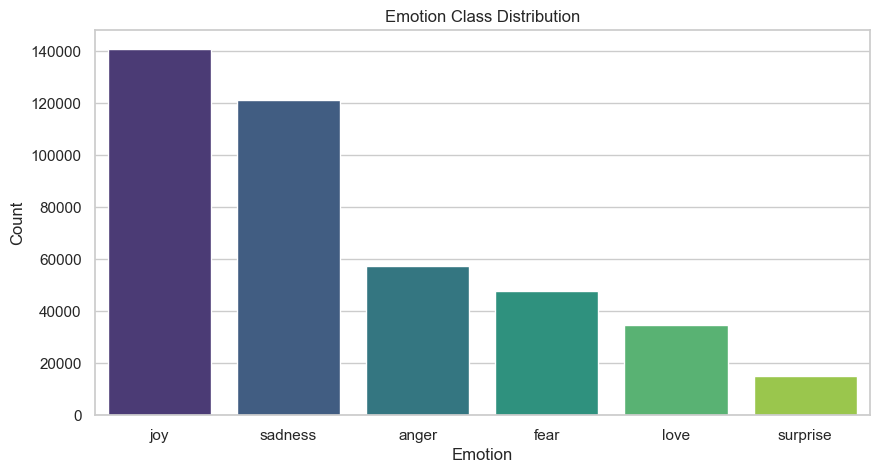

C:\Users\ayoub\AppData\Local\Temp\ipykernel_14520\1052478353.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_name', y='word_count', data=df, palette='magma')


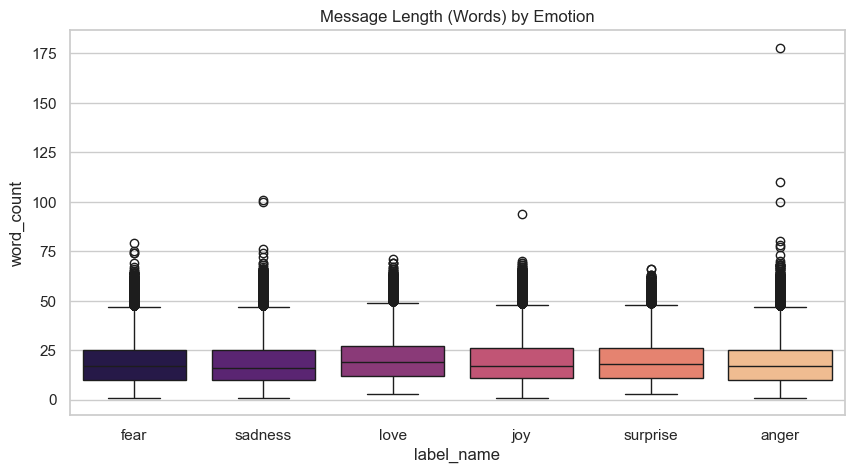

In [35]:
# 1. Emotion Distribution
plt.figure(figsize=(10, 5))
if 'label_name' in df.columns:
    sns.countplot(x='label_name', data=df, palette='viridis', order=df['label_name'].value_counts().index)
    plt.title("Emotion Class Distribution")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.show()
else:
    print("[ERROR] 'label_name' column is missing. Cannot plot distribution.")

# 2. Does text length vary by emotion?
plt.figure(figsize=(10, 5))
if 'label_name' in df.columns:
    sns.boxplot(x='label_name', y='word_count', data=df, palette='magma')
    plt.title("Message Length (Words) by Emotion")
    plt.show()

### 5. Export for Model Training

We save the cleaned dataset for notebook 2 (model training).
Only the columns needed for ML are kept.


In [ ]:
OUTPUT_FILE = "../data/emotions_cleaned_features.csv"

# Select columns to keep
cols_to_keep = ['clean_text', 'label', 'label_name', 'text_len', 'word_count']

try:
    df[cols_to_keep].to_csv(OUTPUT_FILE, index=False)
    print(f"✅ [SUCCESS] Processed dataset saved to: {OUTPUT_FILE}")
    print(f"   Rows: {len(df)}")
    print("   Ready for Notebook 2: Model Training.")
except Exception as e:
    print(f"[ERROR] Could not save file: {e}")

✅ [SUCCESS] Processed dataset saved to: ../data/emotions_cleaned_features.csv
   Rows: 416793
   Ready for Notebook 2: Model Training.
